## Lab-2 11-8-26

Two methods for color image to grayscale:
1. take average of 3 channels and replace each individual pixel value with the individual pixel's channel's average
2. take weighted average of the 3 channels for a given pixel (0.7 R, 0.2 G, 0.1B)


### Q1. Mean average

array([[[124, 156, 151],
        [ 88, 120, 115],
        [ 17,  47,  42],
        ...,
        [137, 139, 127],
        [161, 155, 144],
        [133, 124, 114]],

       [[ 42,  74,  69],
        [103, 135, 130],
        [ 19,  49,  44],
        ...,
        [137, 139, 127],
        [ 77,  73,  62],
        [176, 167, 157]],

       [[ 19,  49,  44],
        [ 31,  61,  56],
        [ 80, 110, 105],
        ...,
        [ 14,  16,   4],
        [  7,   3,   0],
        [114, 108,  97]],

       ...,

       [[154, 138, 139],
        [155, 139, 140],
        [158, 142, 143],
        ...,
        [ 66,  91,  77],
        [ 88, 113,  99],
        [ 75, 100,  86]],

       [[163, 147, 148],
        [159, 143, 144],
        [157, 141, 142],
        ...,
        [ 91, 109,  96],
        [ 86, 104,  91],
        [ 91, 109,  96]],

       [[163, 147, 148],
        [160, 144, 145],
        [157, 141, 142],
        ...,
        [ 93, 110,  97],
        [ 86, 103,  90],
        [ 90, 107,  94]]], dtype=uint8)
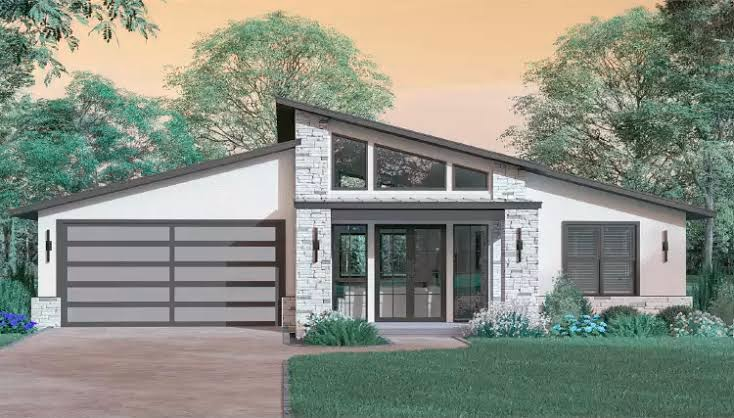

In [ ]:
import cv2
import numpy as np

img = cv2.imread("/content/images.jpg")
if img is None:
  raise FileNotFoundError("Img not found.")

img

In [ ]:
B_channel = img[:,:,0].astype(np.float64)
G_channel = img[:,:,1].astype(np.float64)
R_channel = img[:,:,2].astype(np.float64)

height, width, numChannels = img.shape
new_grayscale_img = np.zeros((height, width))

for i in range(0, height):
  for j in range(0, width):
    avg = (B_channel[i][j] + G_channel[i][j] + R_channel[i][j])/3
    new_grayscale_img[i][j] = avg

new_grayscale_img

print(img.dtype)
print(B_channel.dtype)

array([[143.66666667, 107.66666667,  35.33333333, ..., 134.33333333,
        153.33333333, 123.66666667],
       [ 61.66666667, 122.66666667,  37.33333333, ..., 134.33333333,
         70.66666667, 166.66666667],
       [ 37.33333333,  49.33333333,  98.33333333, ...,  11.33333333,
          3.33333333, 106.33333333],
       ...,
       [143.66666667, 144.66666667, 147.66666667, ...,  78.        ,
        100.        ,  87.        ],
       [152.66666667, 148.66666667, 146.66666667, ...,  98.66666667,
         93.66666667,  98.66666667],
       [152.66666667, 149.66666667, 146.66666667, ..., 100.        ,
         93.        ,  97.        ]])

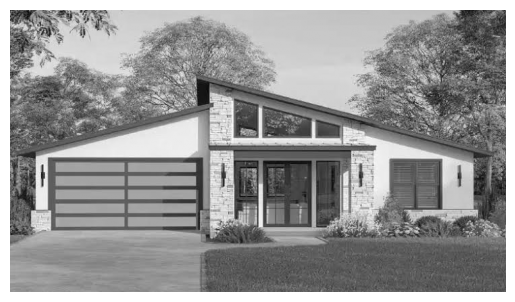

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(new_grayscale_img, cmap='gray')
plt.axis('off')
plt.show()

### Q2. Weighted average

now since weighted is value between 0 and 1, i don't need to convert the channels to bigger matrix.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/images.jpg")

if img is None:
    raise FileNotFoundError("Img not found.")

B_channel = img[:, :, 0].astype(np.float64)
G_channel = img[:, :, 1].astype(np.float64)
R_channel = img[:, :, 2].astype(np.float64)

height, width, numChannels = img.shape

w_r = float(input("Enter weight for R channel (0-1): "))
w_g = float(input("Enter weight for G channel (0-1): "))
w_b = float(input("Enter weight for B channel (0-1): "))

if not (0 <= w_r <= 1 and 0 <= w_g <= 1 and 0 <= w_b <= 1):
    raise ValueError("Each weight must be between 0 and 1.")

if not np.isclose(w_r + w_g + w_b, 1.0):
    raise ValueError(f"Weights must sum to 1, got {w_r + w_g + w_b}")

new_grayscale_img_weighted = np.zeros((height, width))

for i in range(height):
    for j in range(width):
        new_grayscale_img_weighted[i][j] = ((w_r * R_channel[i][j]) + (w_g * G_channel[i][j]) + (w_b * B_channel[i][j]))

plt.imshow(new_grayscale_img_weighted, cmap='gray')
plt.axis('off')
plt.show()


##### My Notes:

overflow because img is uint8 which only stores from 0-255 <br>
for example, if three pixel values are:
200 + 180 + 150 = 530

but NumPy is doing the addition as uint8, 530 cannot be represented. It wraps around modulo 256: 530 % 256 = 18, so effectively getting 18 / 3 = 6 instead of 530 / 3 = 176.67

hence need to convert to larger channels before adding
```
B_channel = img[:, :, 0].astype(np.float64)
G_channel = img[:, :, 1].astype(np.float64)
R_channel = img[:, :, 2].astype(np.float64)
```

uint8, float64 etc are numpy dtypes

This doesn't work cuz this means -> Once you have calculated the answer, store that answer as float64, doesn't mean -> Do all calculations involving this assignment as float64.

overflow happens at this stage when avg is being assigned <br>
-> `(B_channel[i][j] + G_channel[i][j] + R_channel[i][j])` <br>
uint8 + uint8 + uint8 is calculated and the result exceeds uint8 and stores exceed value % 256 and storing in bigger dtype no. Need to convert to bigger values and then compute result and store in bigger dtype hi

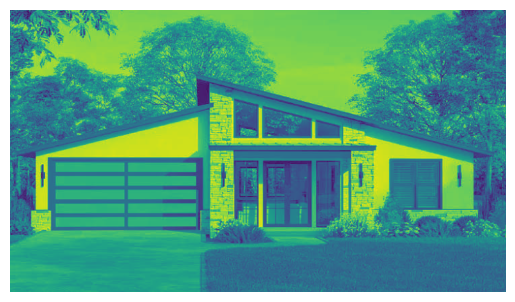

In [ ]:
"""import matplotlib.pyplot as plt

plt.imshow(new_grayscale_img)
plt.axis('off')
plt.show()"""

imshow vs show diff? dono kyu chahiye?

- plt.imshow() takes numerical data (eg numpy array) and translates it into colors. Calling it alone creates the image object in computer memory but will not open a new window if you are running a standard Python script.
- plt.show() tells the backend to open the GUI window and render all active figures.

greenish-tinted image cuz matplotlib doesn't automatically assume 2d array is grayscale.

For a 2D array, Matplotlib applies a colormap. By default, that's usually viridis.

The colormap takes the  numbers:

0 ─────────────────────────────── 255

and maps them to colors roughly like:

low values → purple/blue <br>
middle     → green <br>
high values → yellow <br>

So the colors are being introduced during visualization.

Need to tell matplotlib to display numbers as gray.
This doesn't change the conversion algorithm at all. It only tells Matplotlib how to visualize the already-converted image:

```
plt.imshow(new_grayscale_img, cmap='gray')
plt.axis('off')
plt.show()
```

Now:

0   → black <br>
127 → gray <br>
255 → white <br>
